# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np

## Possible Rarities and its order

In [2]:
# Rarity Order for sorting
# Higher value means rarer card
rarityOrder = {
    "Common": 10,
    "Uncommon": 20,
    "Rare": 30,                         # Regular
    "Classic Collection": 31,
    "Rare Holo": 40,                    # Holofoil
    "Double Rare": 50,                  # EX
    "Ultra Rare": 60,                   # Unique card classification
    "Rare Ultra": 60,                   # Unique card classification
    "Rare Holo Star": 61,
    "Rare Prime": 61,
    "Rare Holo LV.X": 61,
    "Rare Holo EX": 61,
    "Rare Holo GX": 61,
    "LEGEND": 61,
    "Rare BREAK": 61,
    "Amazing Rare": 61,
    "Rare Prism Star": 61,
    "Rare ACE": 61,
    "ACE SPEC Rare": 61,
    "Radiant Rare": 62,
    "Rare Holo V": 63,
    "Rare Holo VSTAR": 64,
    "Rare Holo VMAX": 65,
    "Trainer Gallery Rare Holo": 66,
    "Rare Secret": 70,                  # Out of numbers
    "Rare Shining": 71,                 # Shiny Pokemon
    "Shiny Rare": 72,                   # Shiny Pokemon
    "Rare Shiny": 72,                   # Shiny Pokemon
    "Rare Shiny GX": 73,                # Shiny Pokemon
    "Shiny Ultra Rare": 73,             # Shiny Pokemon
    "Rare Rainbow": 74,
    "Illustration Rare": 75,            # Full-Art
    "Special Illustration Rare": 76,    # Full-Art
    "Hyper Rare": 80,                   # Gold Cards
    "Promo": 90                         # Event Cards
}

# List of grade order
# Number has no meaning
gradeOrder = {
    'holo-nearmint': 1,
    'holo-good': 2,
    'holo-played': 3,
    'holo-used' : 4, 
    'holo-poor': 5,
    'reverse-nearmint': 6,
    'reverse-good': 7,
    'reverse-played': 8,
    'reverse-used': 9,
    'reverse-poor': 10,
    'normal-nearmint': 11,
    'normal-good': 12,
    'normal-played': 13,
    'normal-used': 14,
    'normal-poor': 15
}

# Dataframe

In [3]:
# Read data
df = pd.read_csv('merged_pokemon_data_with_artist.csv')

# Process Data
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df['Month'] = df['Month'].dt.strftime('%Y-%m')
df = df.sort_values('Month')

df['Average'] = pd.to_numeric(df['Average'], errors='coerce')

# Sort the unique rarities in the DataFrame using rarityOrder
sorted_rarities = sorted(df['Rarity'].dropna().unique(), key=lambda r: rarityOrder.get(r, float('inf')), reverse=True)
sorted_grades = sorted(df['Grade'].dropna().unique(), key=lambda r: gradeOrder.get(r, float('inf')), reverse=False)

# Data processing

In [4]:
# Take the max price per card (to remove duplicates over months)
grouped = df.groupby(['Set ID', 'Number', 'Name', 'Artist', 'Rarity', 'Grade'], as_index=False)['Average'].max()

# Sort set IDs for nicer x-axis plotting
grouped['Set ID'] = grouped['Set ID'].astype(str)
sorted_set_ids = sorted(grouped['Set ID'].unique(), key=lambda x: (x[:4], int(x[4:]) if x[4:].isdigit() else 0))

# Graph in specific price range

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\3249763598.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Paired', len(artists))


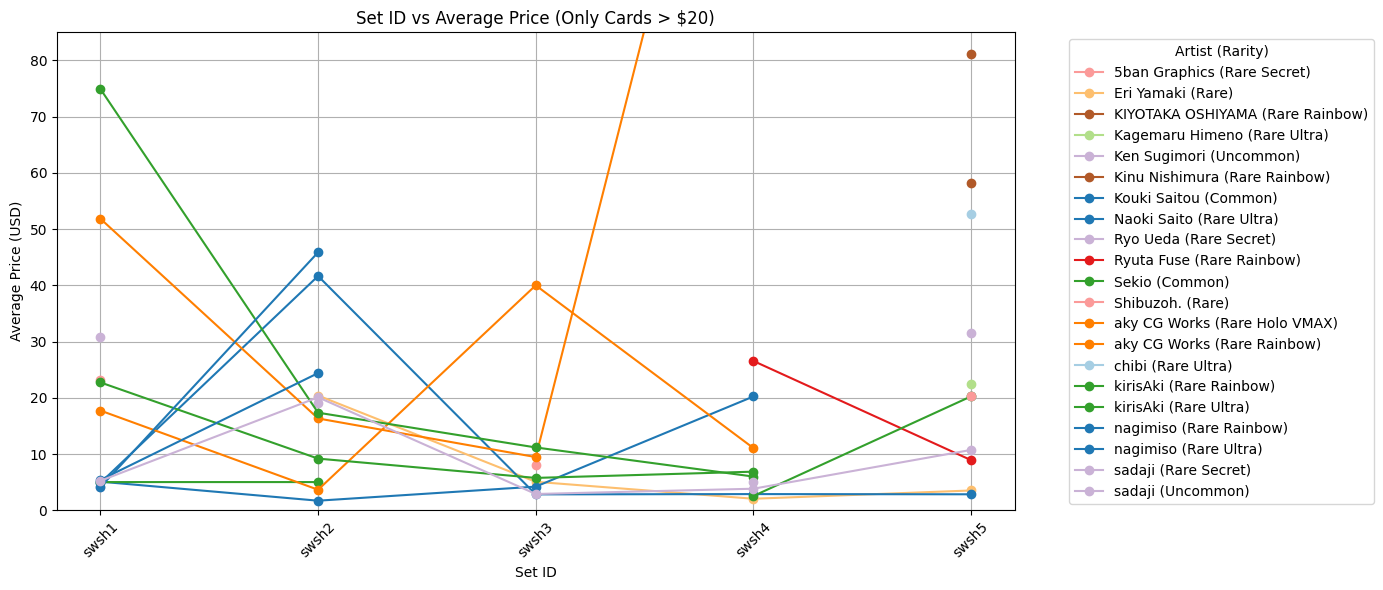

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
plt.figure(figsize=(14, 6))

# Get unique artists
artists = grouped['Artist'].unique()

# Create a colormap with enough distinct colors for each artist
cmap = plt.cm.get_cmap('Paired', len(artists))
artist_colors = {artist: cmap(i) for i, artist in enumerate(artists)}

# Plot line graph
for ((artist, rarity), sub) in grouped.groupby(['Artist', 'Rarity']):
    avg_by_set = sub.groupby('Set ID')['Average'].max().reindex(sorted_set_ids)

    min_price = 20
    max_price = 100

    if ((avg_by_set > min_price * 100) & (avg_by_set < max_price * 100)).any():
        plt.plot(
            avg_by_set.index,
            avg_by_set.values / 100,
            marker='o',
            color=artist_colors[artist],  # Use the same color for the same artist
            label=f'{artist} ({rarity})'
        )

plt.title(f'Set ID vs Average Price (Only Cards > ${min_price})')
plt.xlabel('Set ID')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.legend(title='Artist (Rarity)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Set y-axis range
plt.ylim(0, 85)

plt.tight_layout()
plt.show()


# Price per rarity

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


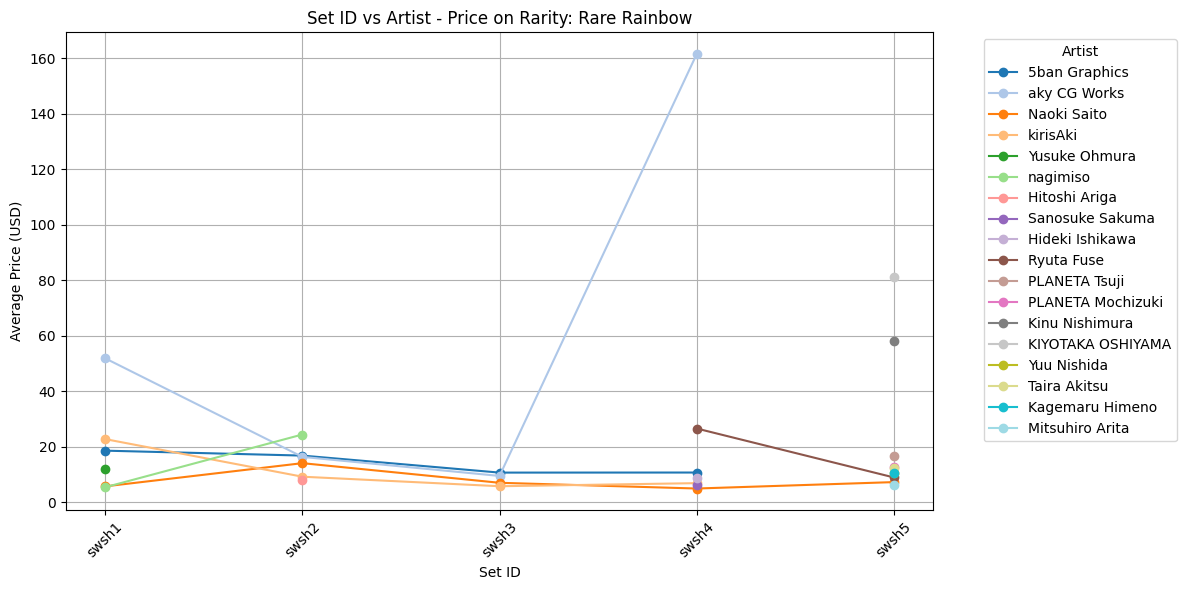

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


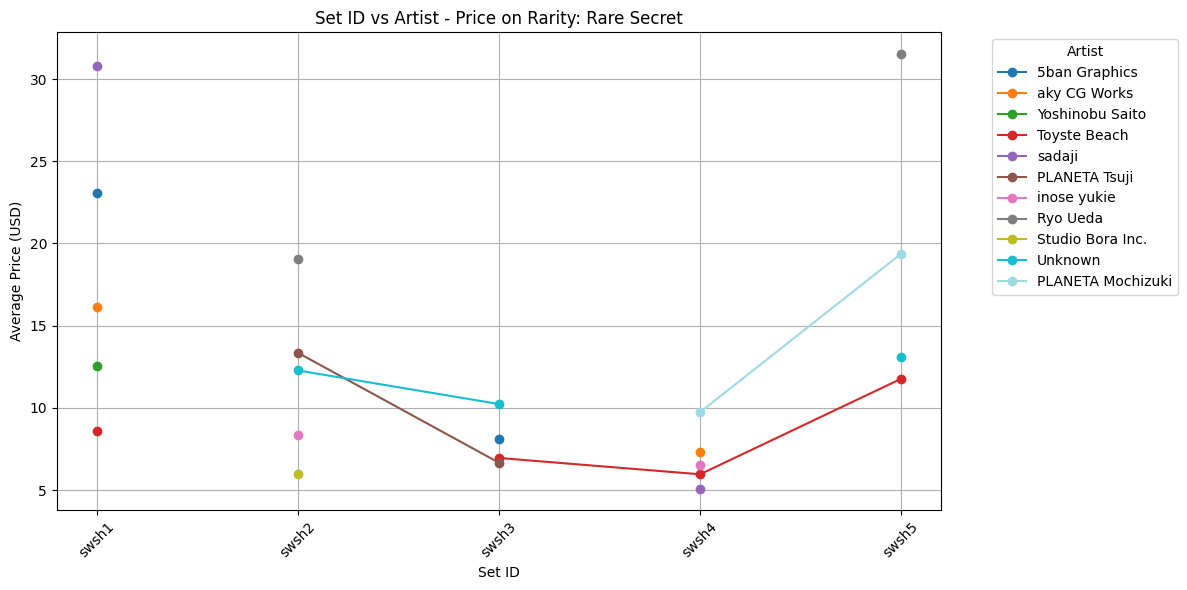

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


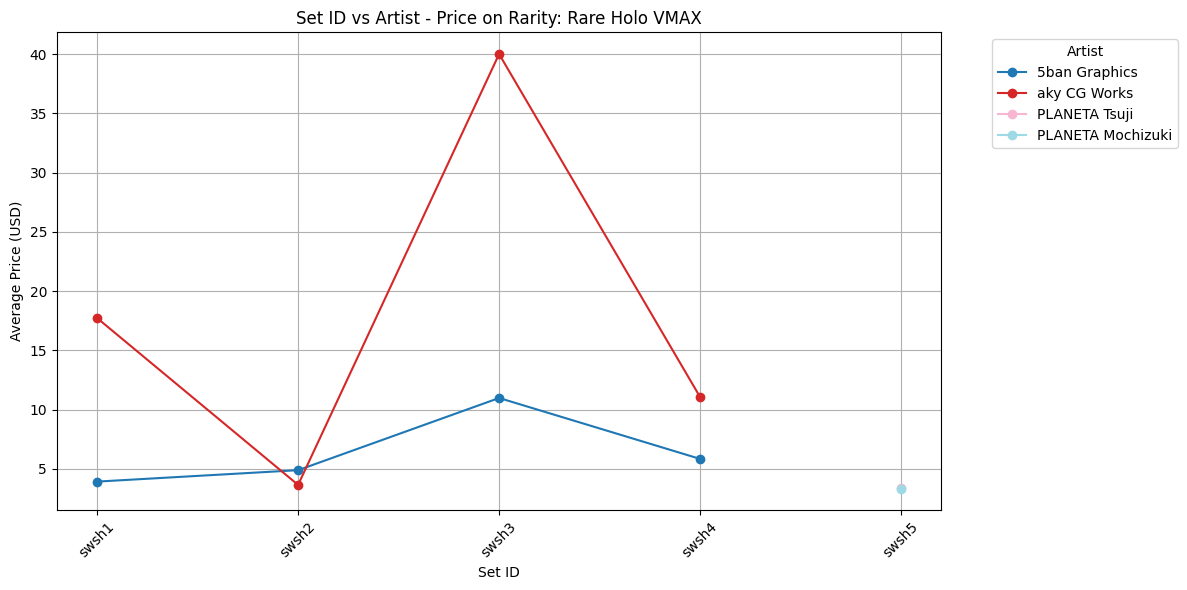

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


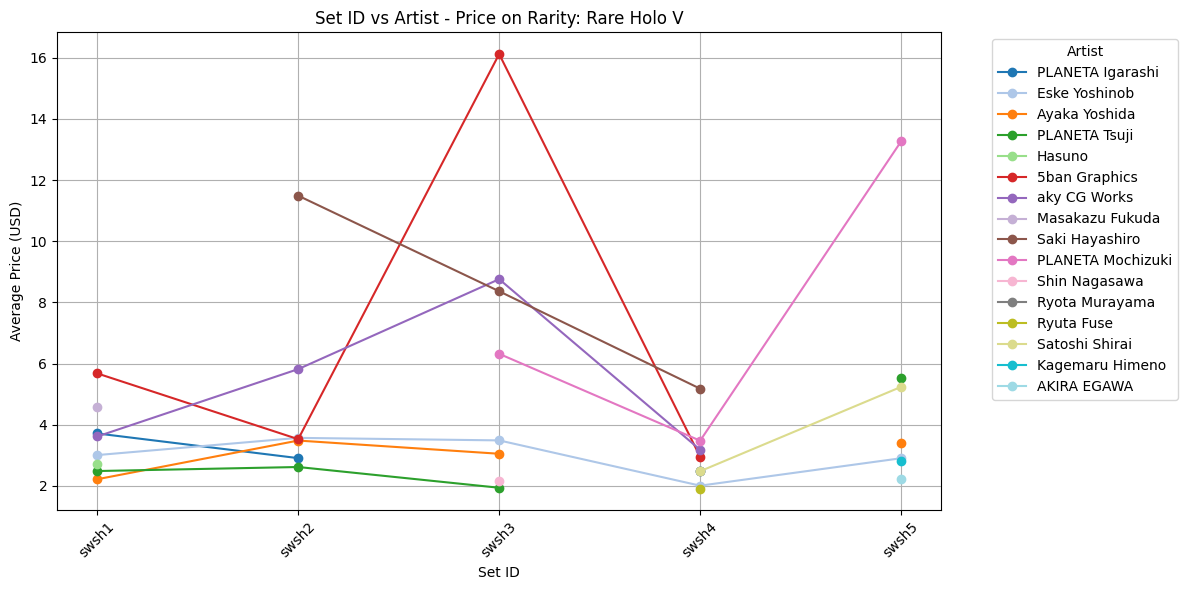

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


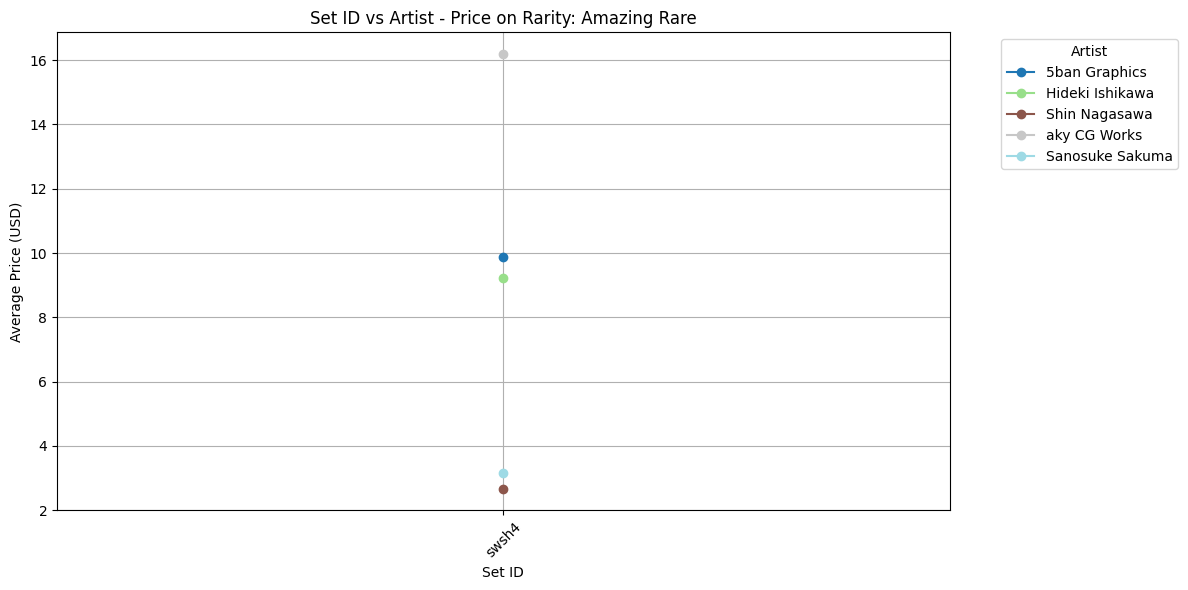

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


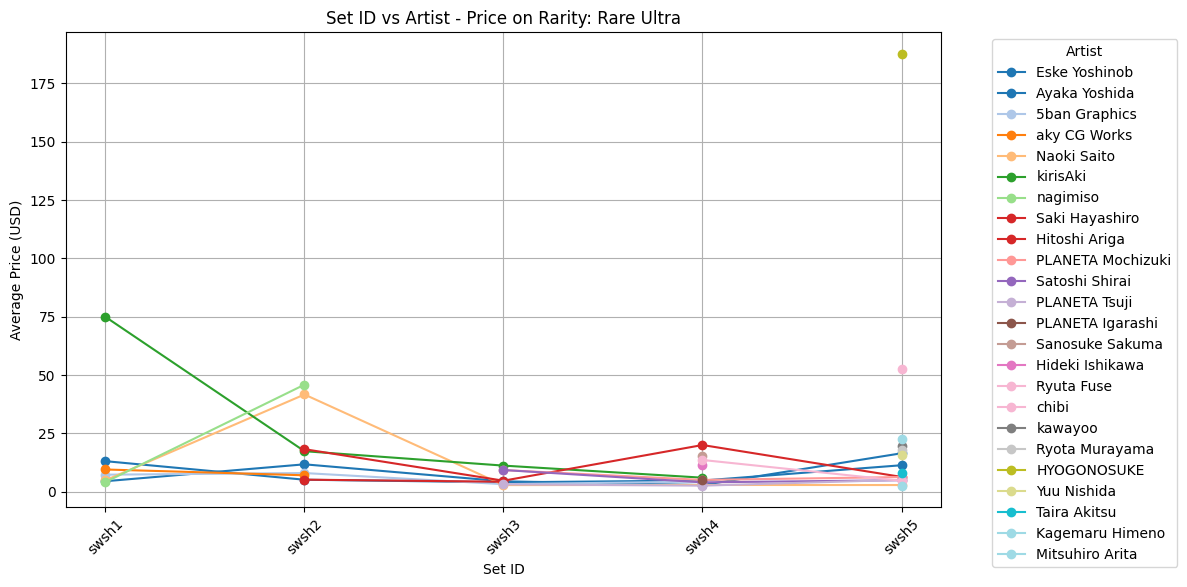

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))


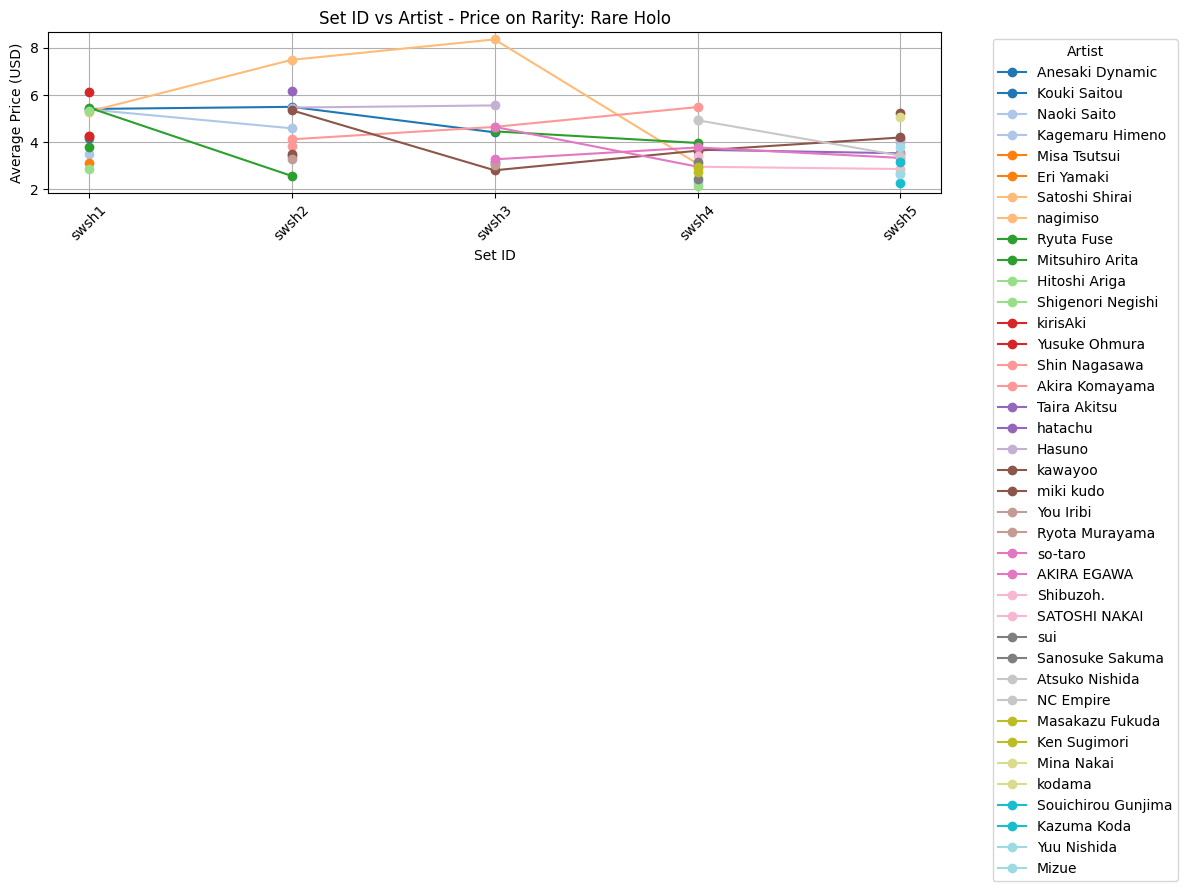

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))
C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


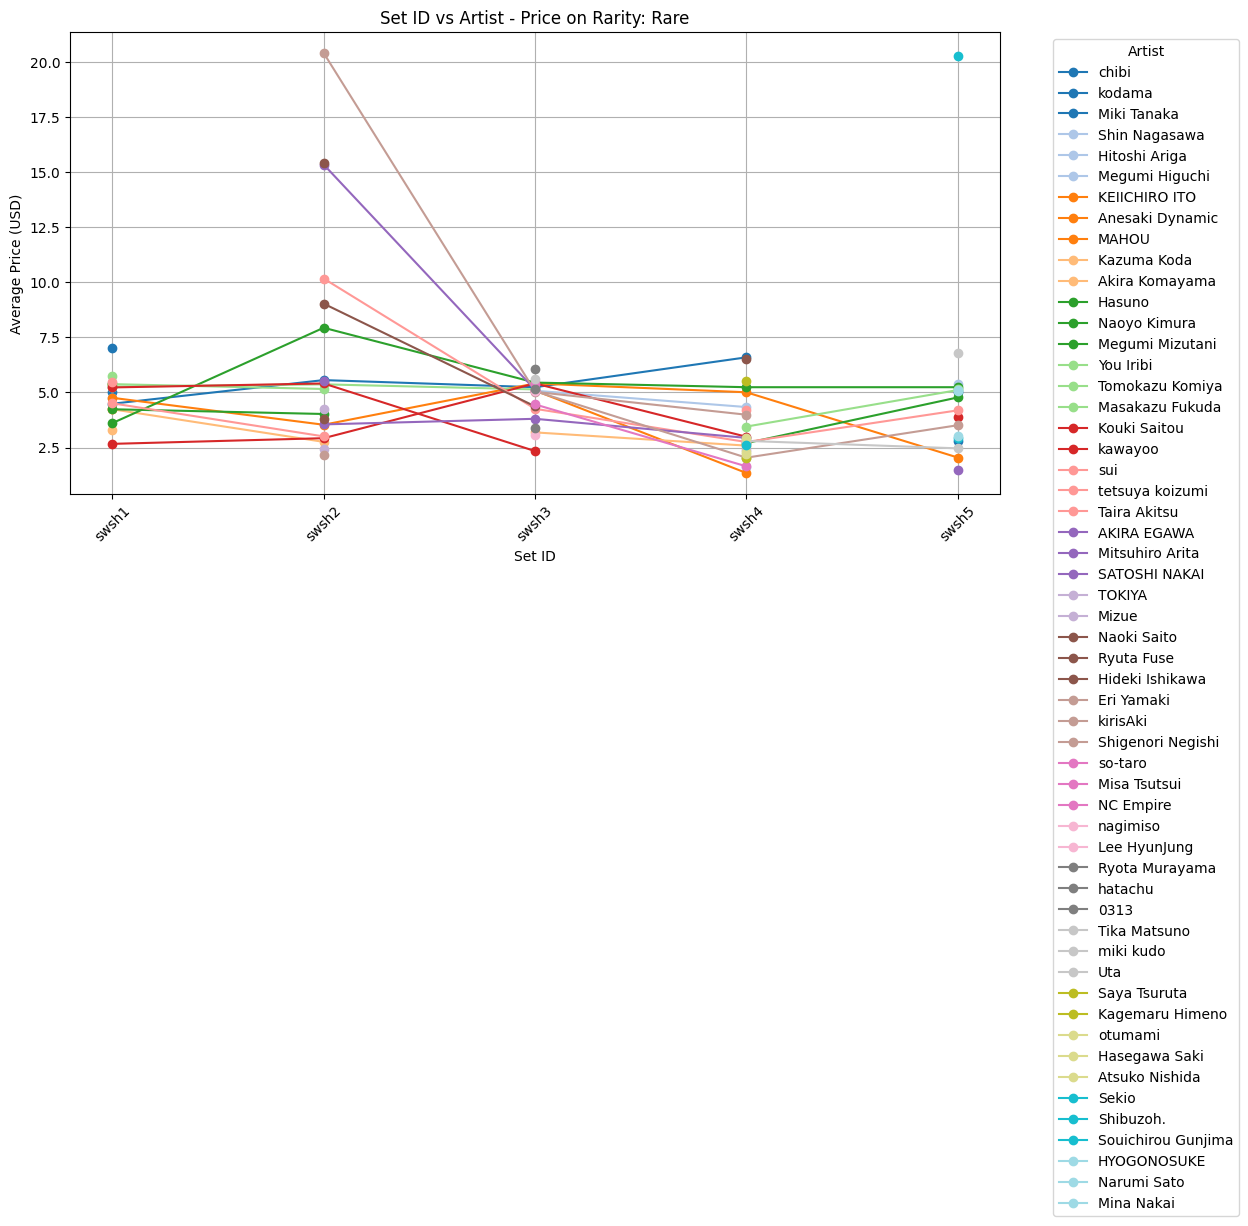

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))
C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


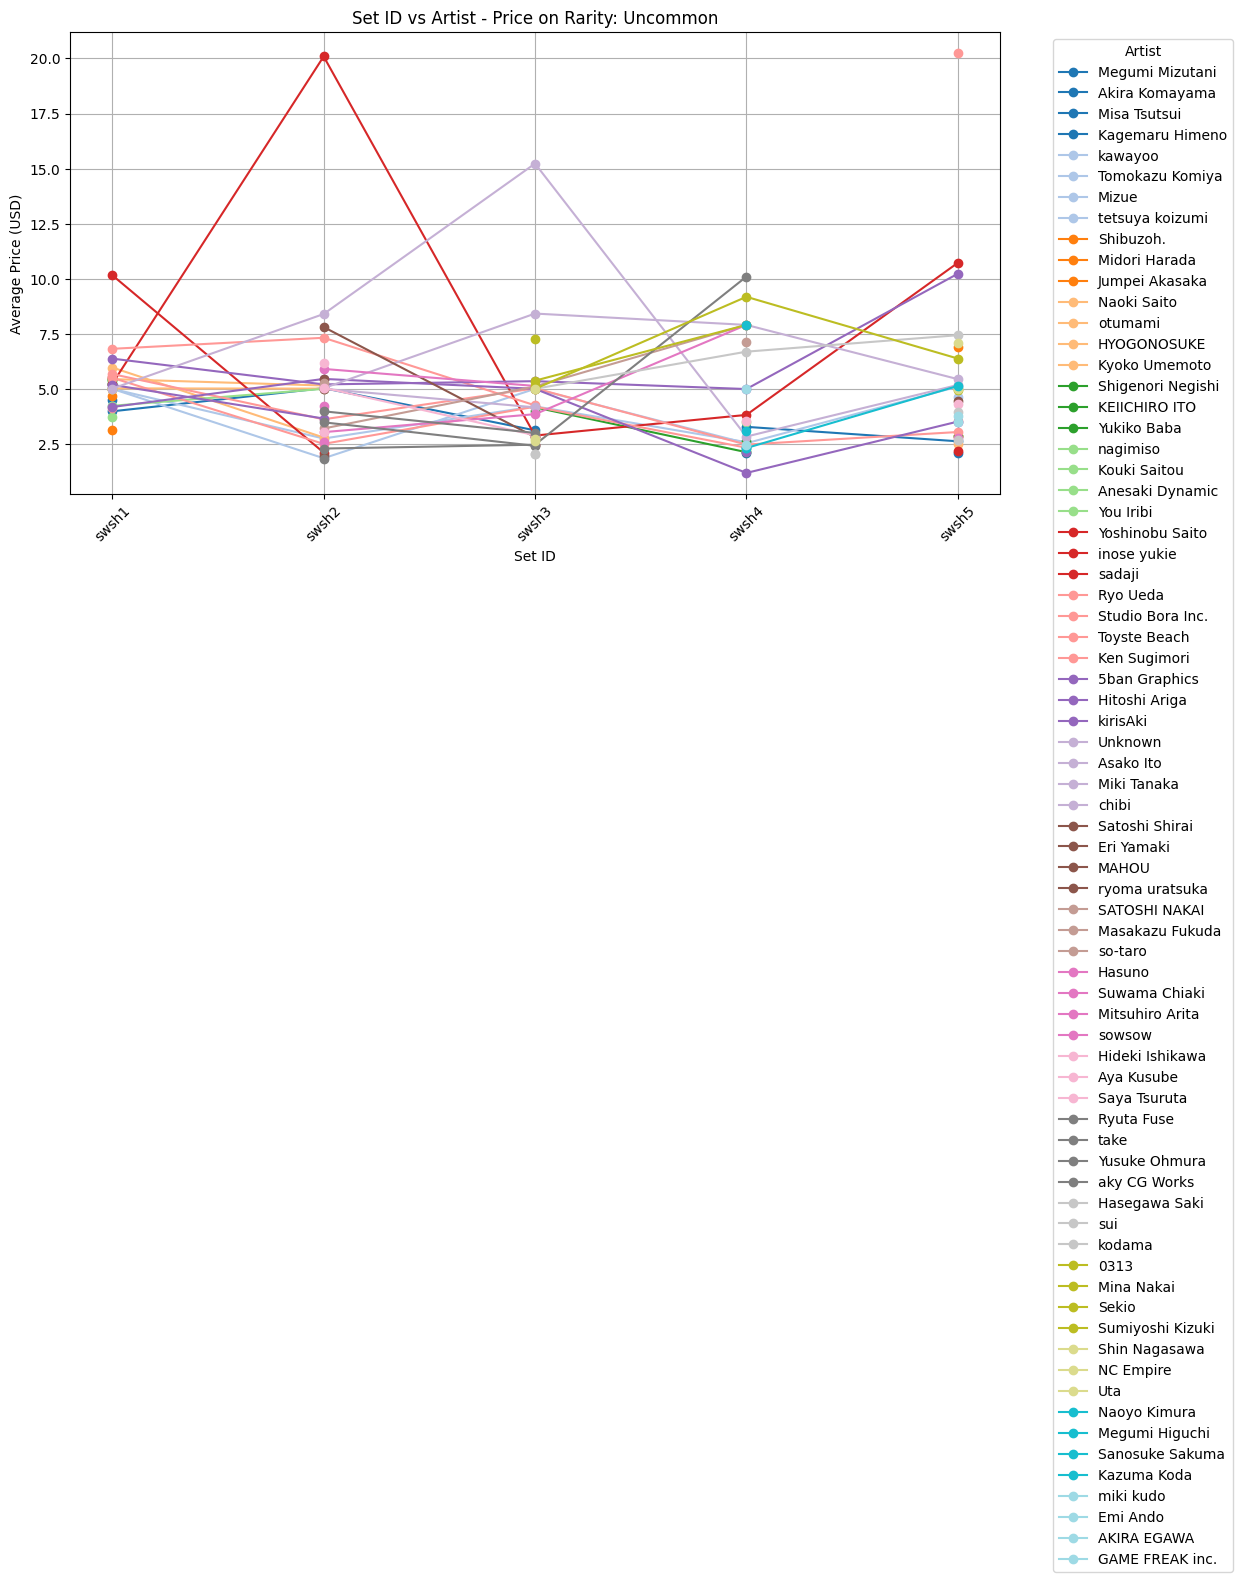

C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(artists))
C:\Users\jiunk\AppData\Local\Temp\ipykernel_9760\30891742.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


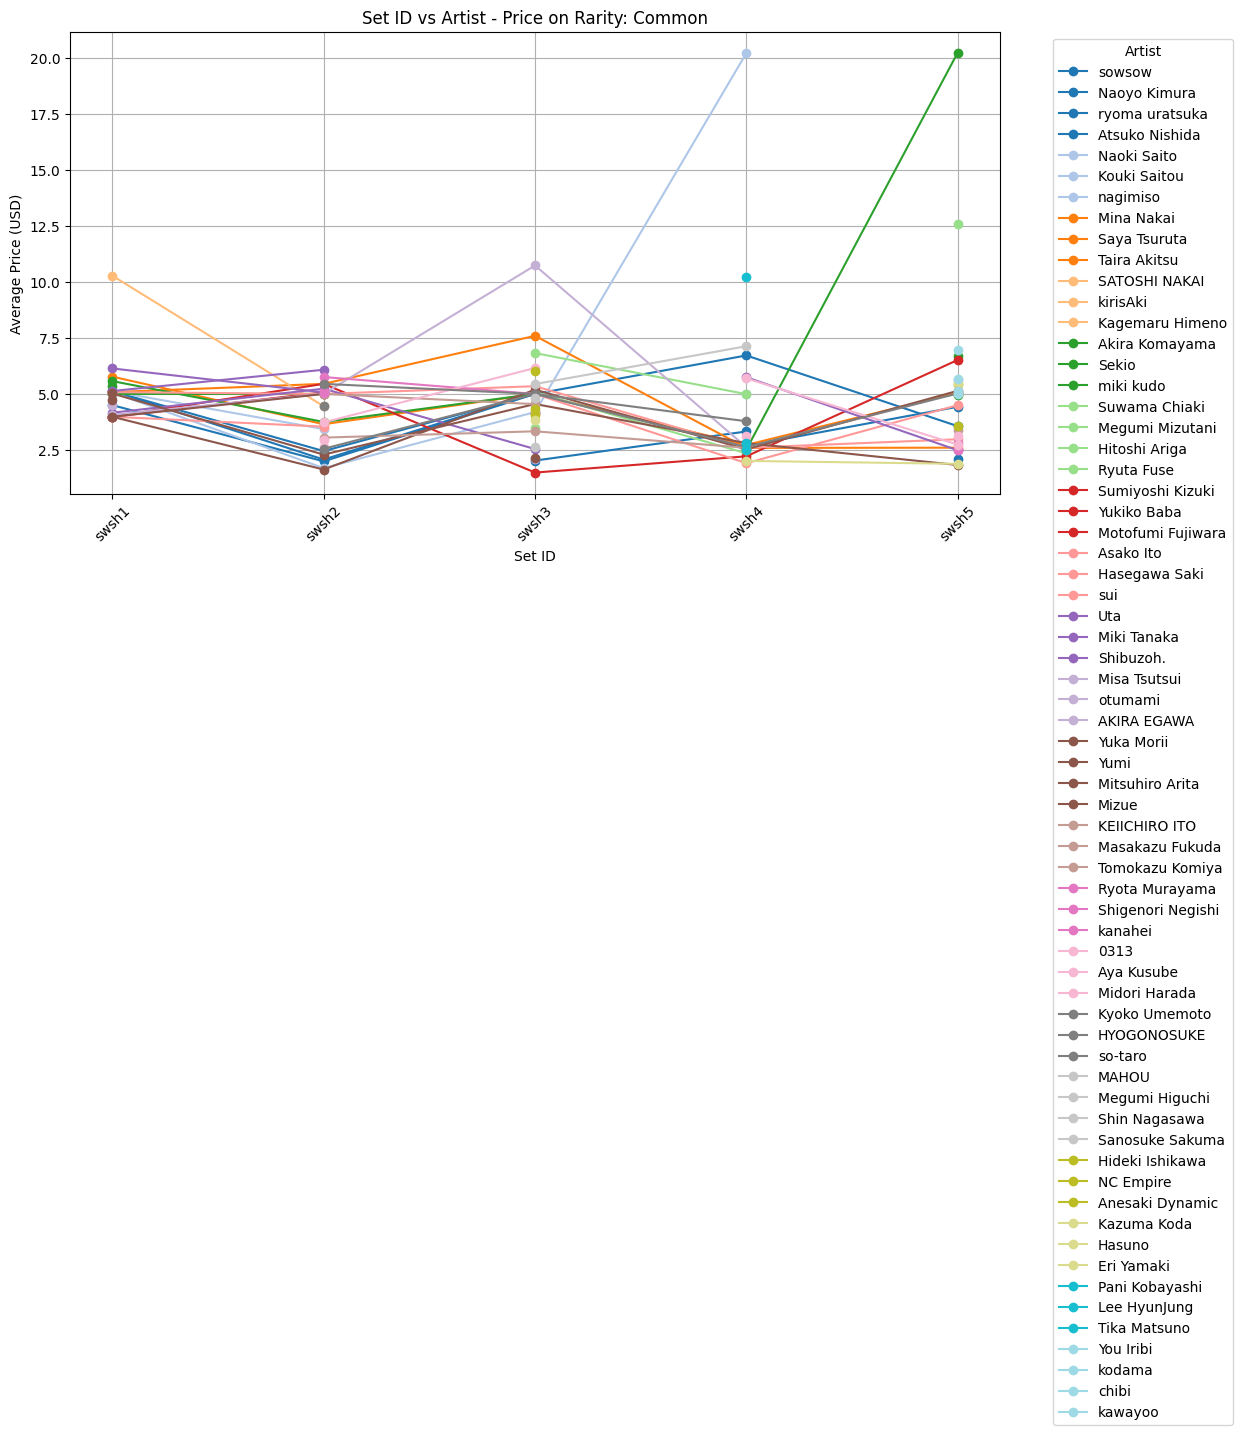

In [6]:
# Loop over each rarity to create a separate plot
for rarity in sorted_rarities:
    plt.figure(figsize=(12, 6))
    
    # Filter for the current rarity
    subset = grouped[grouped['Rarity'] == rarity]

    # Get the list of artists for the current rarity
    artists = subset['Artist'].unique()

    # Create a colormap with enough distinct colors for each artist
    cmap = plt.cm.get_cmap('tab20', len(artists))
    artist_colors = {artist: cmap(i) for i, artist in enumerate(artists)}

    # Plot line graph
    for artist in artists:
        artist_data = subset[subset['Artist'] == artist]
        # Aggregate again in case artist has multiple cards per Set ID
        artist_avg = artist_data.groupby('Set ID')['Average'].max().reindex(sorted_set_ids)

        # Use the artist's color from the colormap
        plt.plot(
            artist_avg.index,
            artist_avg.values / 100,
            marker='o',
            color=artist_colors[artist],  # Use the mapped color for the artist
            label=artist
        )

    plt.title(f'Set ID vs Artist - Price on Rarity: {rarity}')
    plt.xlabel('Set ID')
    plt.ylabel('Average Price (USD)')
    plt.xticks(rotation=45)
    plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
